word2vec는 다음과 같이 어떤 단어에 대한 one-hot encoding vector를 입력으로 받고, embedding layer을 통해 embedding vector로 변환한다.

output layer는 embedding vector을 입력으로 받고, vocabulary size 크기의 probability vector를 출력한다.

이 probability vector의 각 차원은 그 차원에 해당하는 index에 대한 vocabulary내 특정 단어를 예측하는 vector이다.

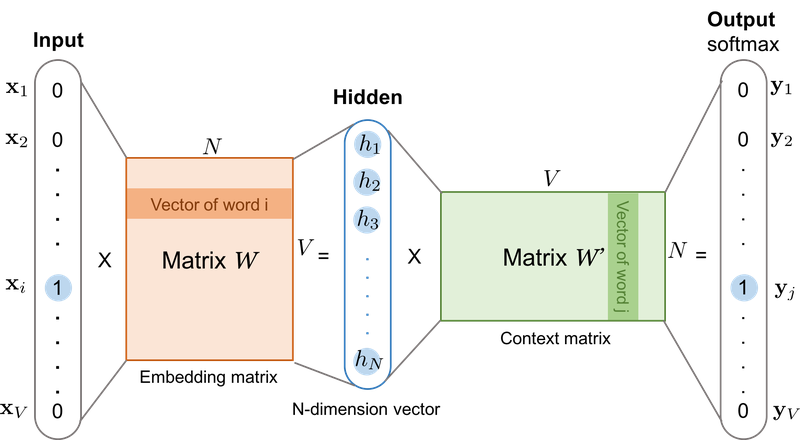

In [ ]:
import torch.nn as nn
import torch
import torch.nn.functional as F

class SkipGram(nn.Module):
  def __init__(self,vocab_size,embedding_size):
    super().__init__()
    self.in_embed=nn.Embedding(vocab_size,embedding_size)
    self.out_embed=nn.Embedding(vocab_size,embedding_size)

  def forward(self,center_words):
    center_embeds=self.in_embed(center_words)
    scores=torch.matmul(center_embeds,self.out_embed.weight.t())
    log_probs=F.log_softmax(scores,dim=-1)
    return log_probs